# 01 · Are genres real?

**The intuition:** liking one song doesn't mean you'll like another of the *same genre* any more than a random song. Maybe genre is a weak proxy for what actually makes songs *sound* alike. We test it — and *show* every step:

1. Do genres look different feature-by-feature? (distributions)
2. How much variance does genre explain? (eta²)
3. Can we predict genre from the sound? (classifier + confusion matrix)
4. Which genres sound alike? (genre-similarity heatmap)
5. Are a song's acoustic neighbors the same genre? (nearest-neighbor lift + a worked example)
6. Do genres separate visually? (PCA)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'analysis'))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
from common import load_genre, load_timeline, AUDIO, zscore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
RNG = 42
df = load_genre()
print(f'{len(df):,} rows · {df.genre.nunique()} genres')

232,724 rows · 26 genres


## Step 1 — Do genres actually look different?
Draw every feature's distribution for every genre (genres ordered by median energy, so the same row = the same genre across all nine panels). If genres were real & distinct, the ridges would sit in clearly different places. A few do (`speechiness` for Comedy, `acousticness` for Classical/Opera); most overlap heavily.

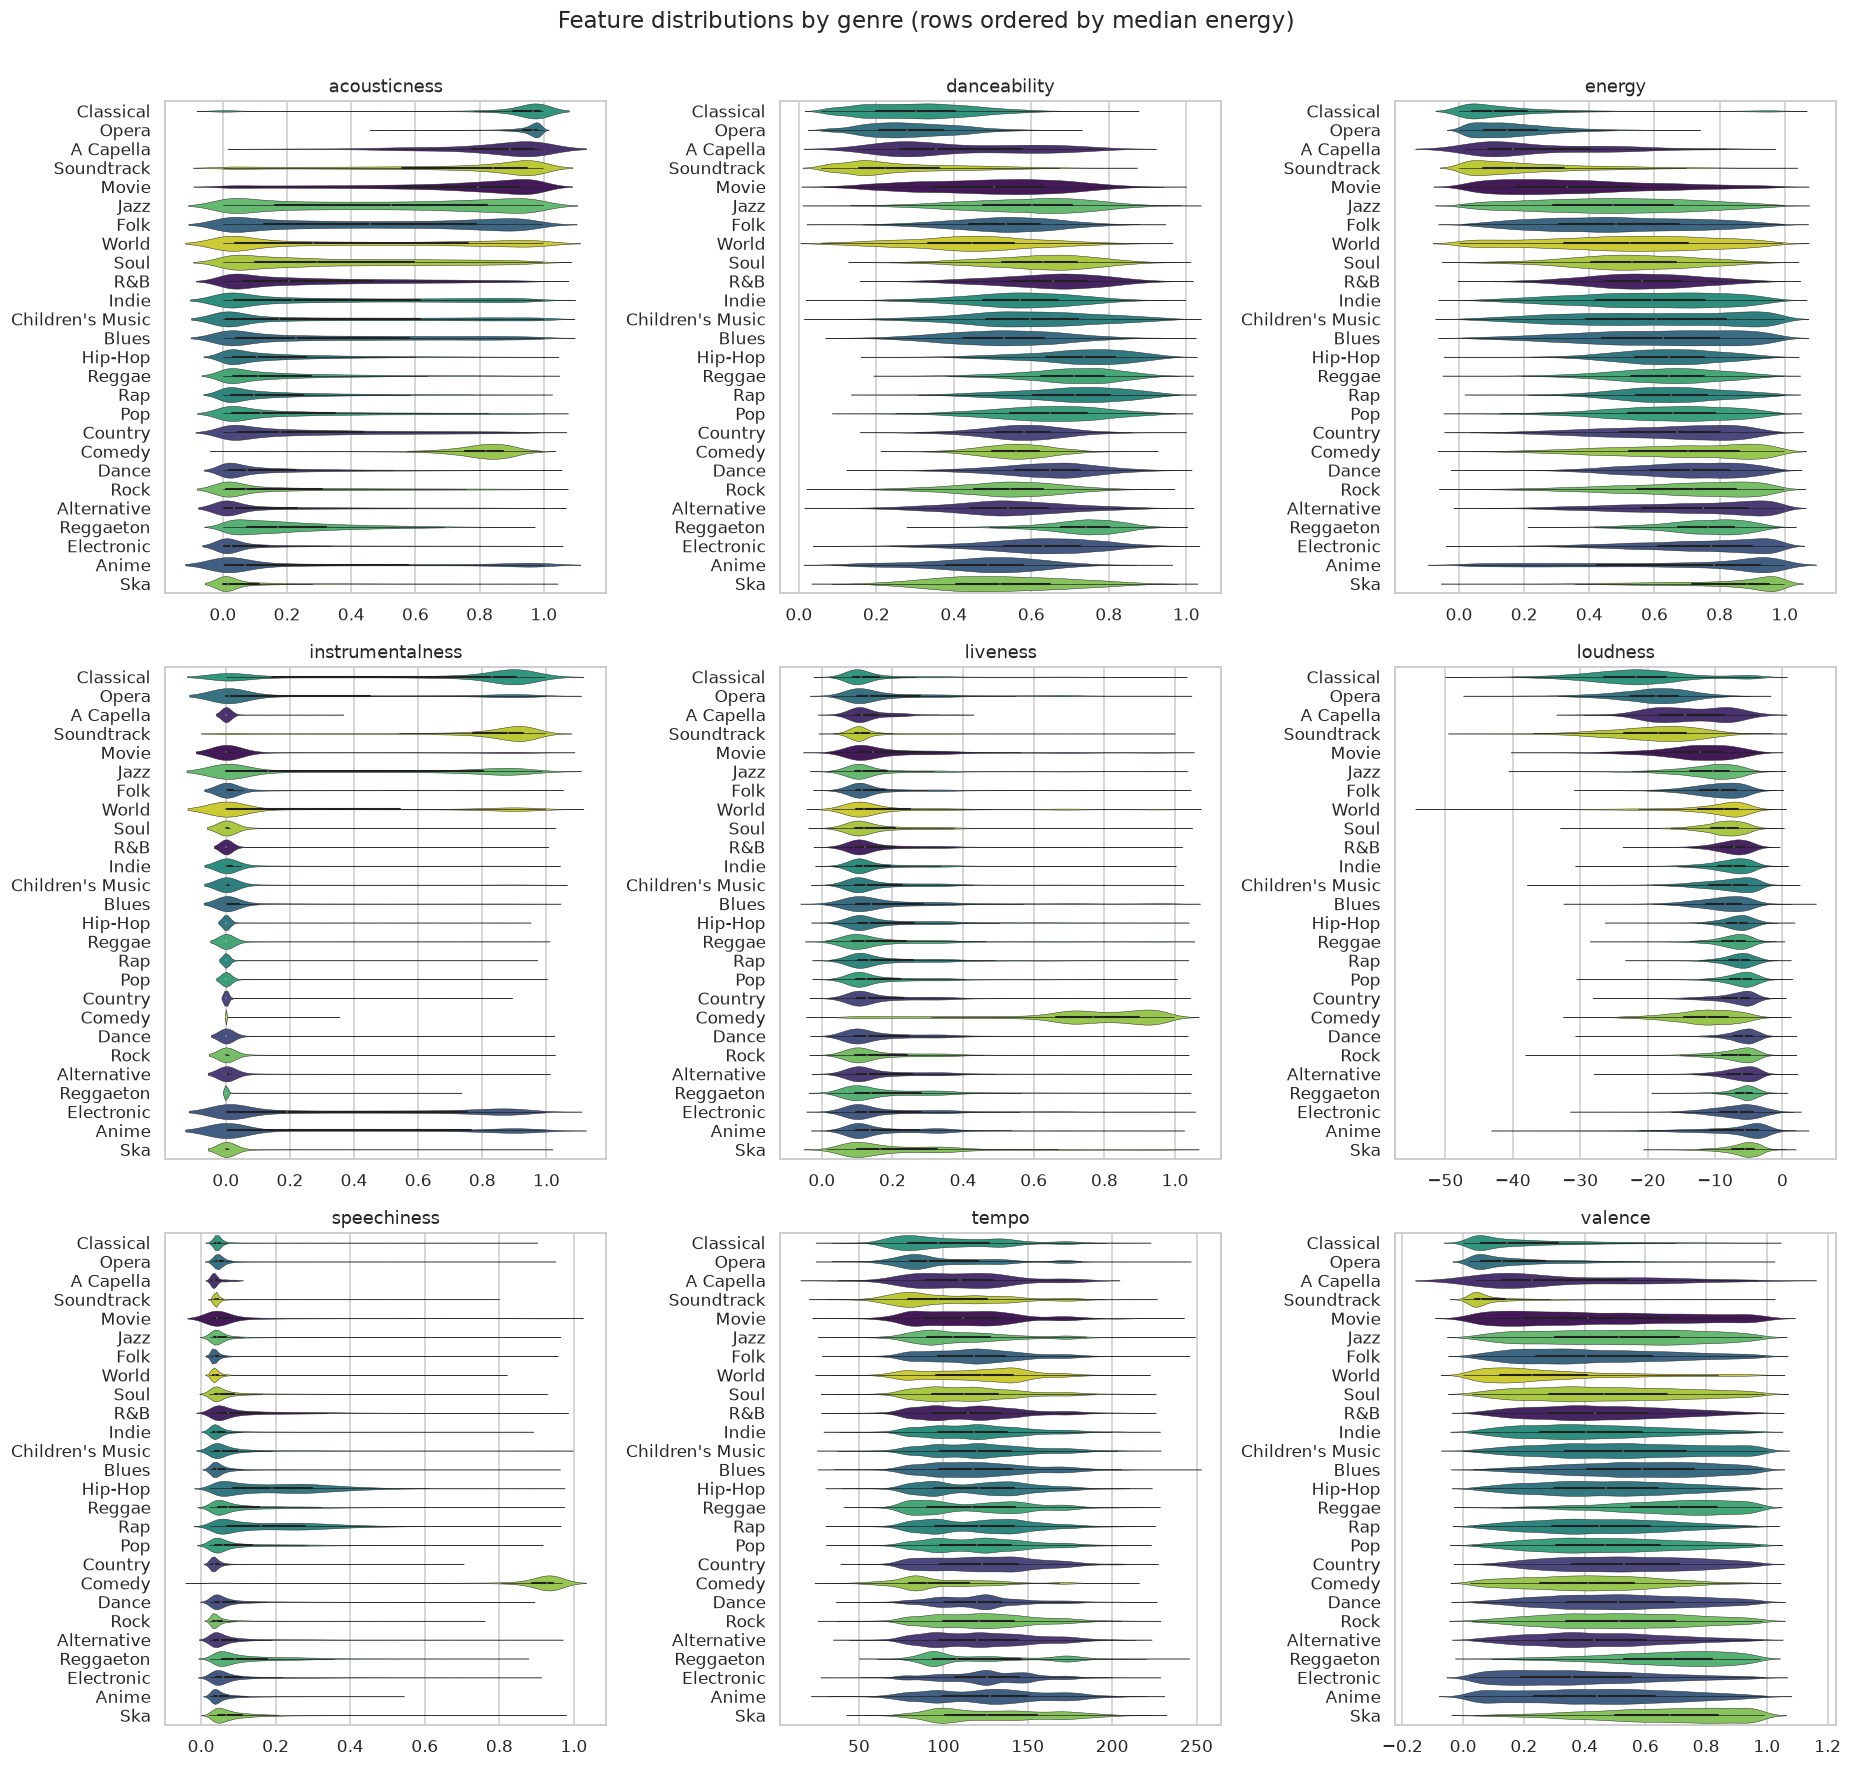

In [2]:
order = df.groupby('genre')['energy'].median().sort_values().index
fig, axes = plt.subplots(3, 3, figsize=(17, 16), sharey=True)
for ax, f in zip(axes.ravel(), AUDIO):
    sns.violinplot(df, x=f, y='genre', order=order, ax=ax, hue='genre',
                   legend=False, density_norm='width', linewidth=.3, palette='viridis')
    ax.set_title(f); ax.set_ylabel(''); ax.set_xlabel('')
    ax.tick_params(labelleft=True)   # repeat genre labels on every panel
fig.suptitle('Feature distributions by genre (rows ordered by median energy)', y=1.003,
             fontsize=15)
plt.tight_layout(); plt.show()

## Step 2 — How much does genre explain? (eta²)
eta² = fraction of a feature's variance that lies *between* genres rather than within them. 1.0 would mean genre fully determines the feature; 0 means genre tells you nothing.

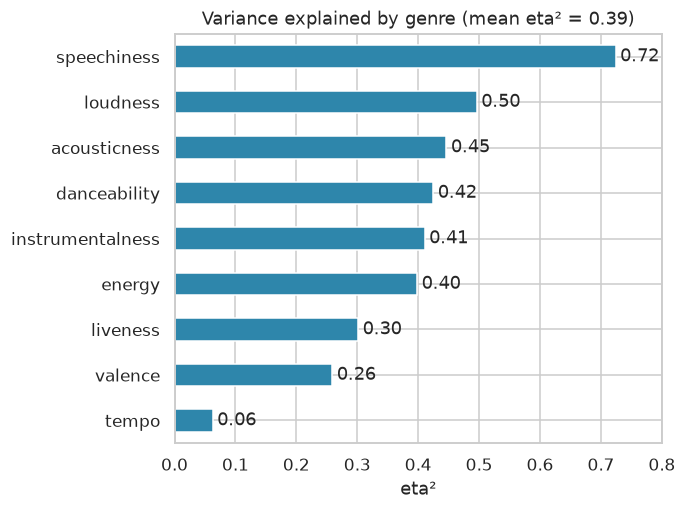

In [3]:
def eta_squared(df, feature, group='genre'):
    grand = df[feature].mean()
    ss_total = ((df[feature] - grand) ** 2).sum()
    ss_between = df.groupby(group)[feature].apply(lambda s: len(s)*(s.mean()-grand)**2).sum()
    return ss_between / ss_total

etas = pd.Series({f: eta_squared(df, f) for f in AUDIO}).sort_values()
ax = etas.plot.barh(color='#2e86ab')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
ax.set_title(f'Variance explained by genre (mean eta² = {etas.mean():.2f})')
ax.set_xlabel('eta²'); ax.set_xlim(0, .8); plt.tight_layout(); plt.show()

**Takeaway:** genre explains ~39% of feature variance on average — strong for `speechiness`, near-zero for `tempo`. Real signal, but far from deterministic.

## Step 3 — Can we predict genre from the sound?
Dedupe to one row per track (avoids leakage), standardize the 9 features, train two classifiers. The bar to beat is *always guess the biggest genre*.

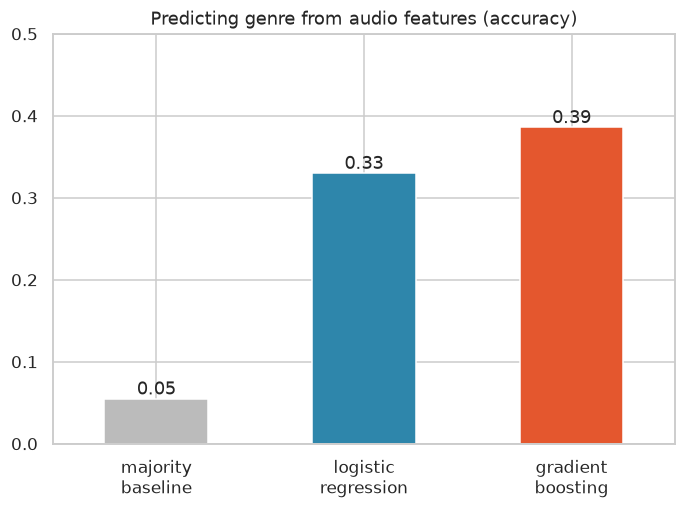

In [4]:
uniq = df.sort_values('track_id').drop_duplicates('track_id').reset_index(drop=True)
X = zscore(uniq)
y = uniq['genre'].to_numpy()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RNG, stratify=y)
baseline = pd.Series(ytr).value_counts(normalize=True).max()
lr = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
gb = HistGradientBoostingClassifier(random_state=RNG).fit(Xtr, ytr)
pred = gb.predict(Xte)
scores = pd.Series({'majority\nbaseline': baseline,
                    'logistic\nregression': accuracy_score(yte, lr.predict(Xte)),
                    'gradient\nboosting': accuracy_score(yte, pred)})
ax = scores.plot.bar(color=['#bbb','#2e86ab','#e4572e'], rot=0)
ax.bar_label(ax.containers[0], fmt='%.2f'); ax.set_ylim(0, .5)
ax.set_title('Predicting genre from audio features (accuracy)'); plt.tight_layout(); plt.show()

~0.39 vs a 0.055 baseline = **7× better than chance, but wrong ~61% of the time.** The confusion matrix shows *where* it fails — bright off-diagonal cells are genres that get mistaken for each other:

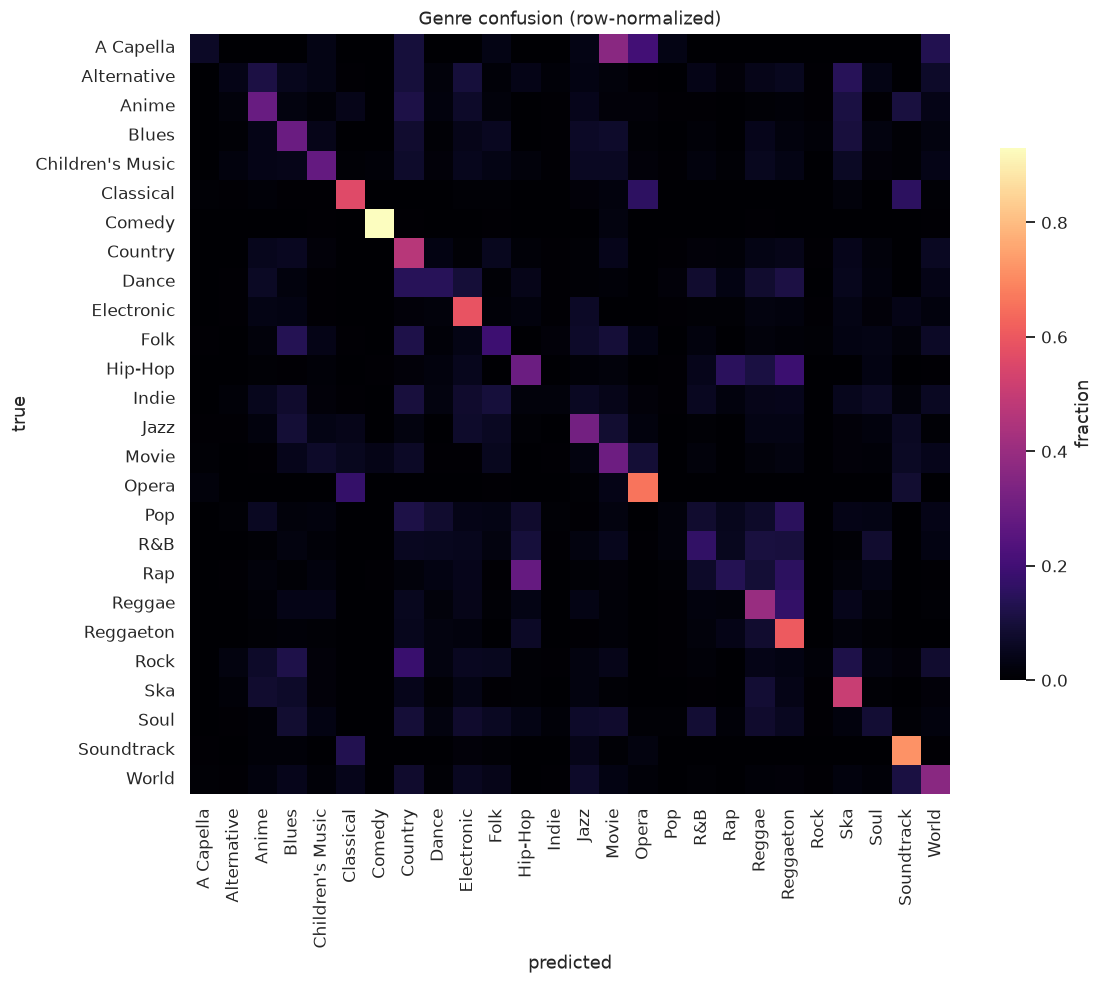

In [5]:
labels = sorted(np.unique(y))
cm = confusion_matrix(yte, pred, labels=labels, normalize='true')
plt.figure(figsize=(11, 9))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='magma',
            square=True, cbar_kws={'shrink': .7, 'label': 'fraction'})
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Genre confusion (row-normalized)')
plt.tight_layout(); plt.show()

**Takeaway:** a few genres are acoustically crisp (Comedy = spoken word, Classical, Opera), but Pop, Rock, R&B, Rap/Hip-Hop bleed into each other. The mess *is* the finding.

## Step 4 — Which genres sound alike?
Distance between genre 'centroids' in feature space, clustered. Genres that clump together are acoustically near-indistinguishable (e.g. Rap/Hip-Hop, or the acoustic-leaning cluster).

/workspaces/spotify-tracks/.venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/workspaces/spotify-tracks/.venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


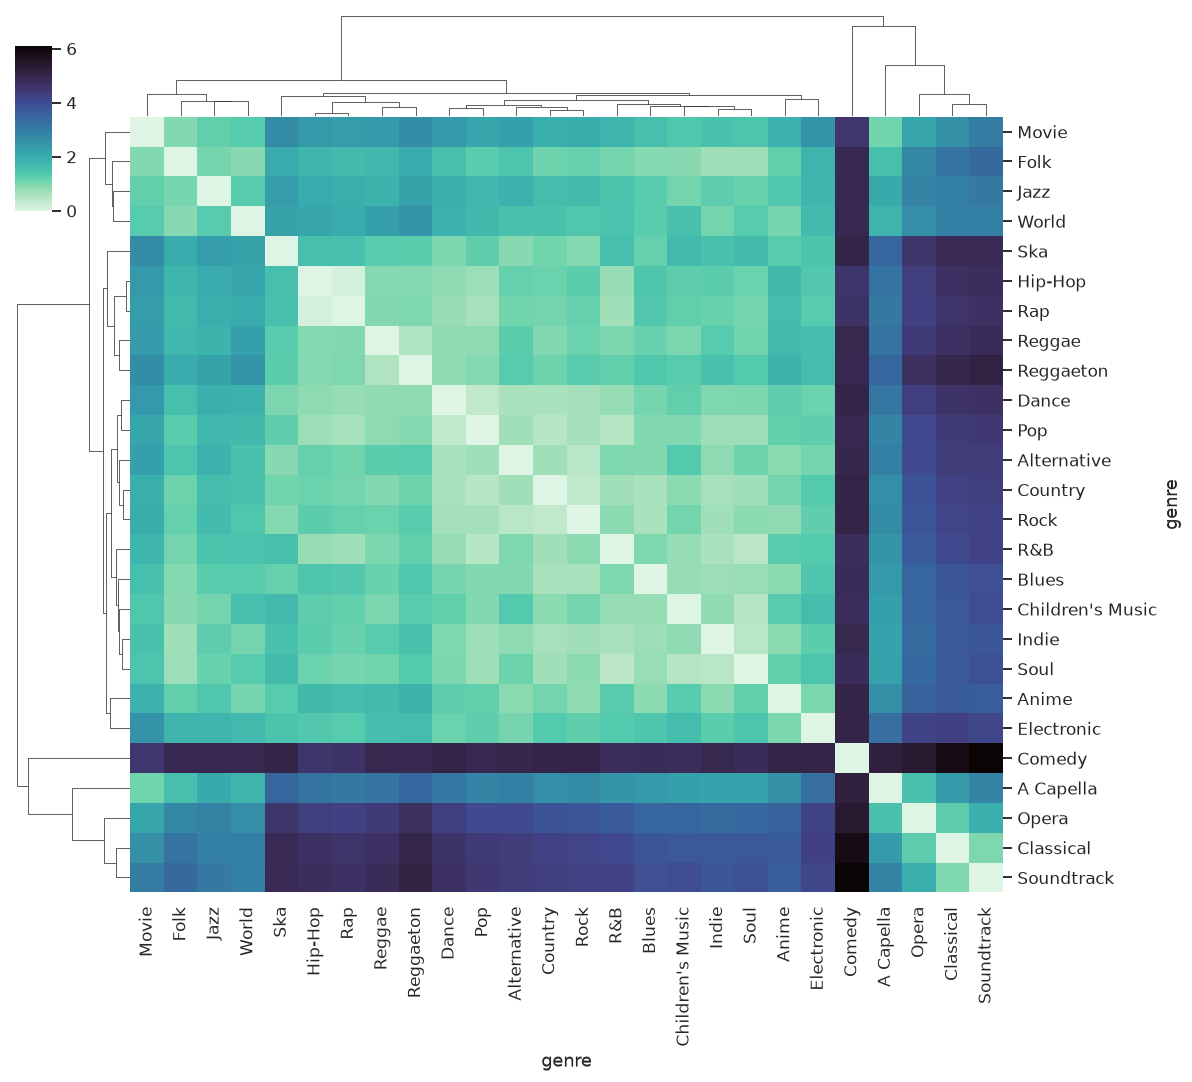

In [6]:
cent = pd.DataFrame(X, columns=AUDIO).assign(genre=y).groupby('genre').mean()
from scipy.spatial.distance import pdist, squareform
dist = pd.DataFrame(squareform(pdist(cent)), index=cent.index, columns=cent.index)
sns.clustermap(dist, cmap='mako_r', figsize=(11, 10),
               dendrogram_ratio=.12, cbar_pos=(.02, .8, .03, .15))
plt.show()

## Step 5 — Are your acoustic neighbors the same genre?
The intuition made literal: for a sample of tracks, of the 10 nearest songs in feature space, what fraction share the genre — versus a random pair?

neighbors sharing genre: 25.4%   random-pair base rate: 4.3%   lift: 6.0x


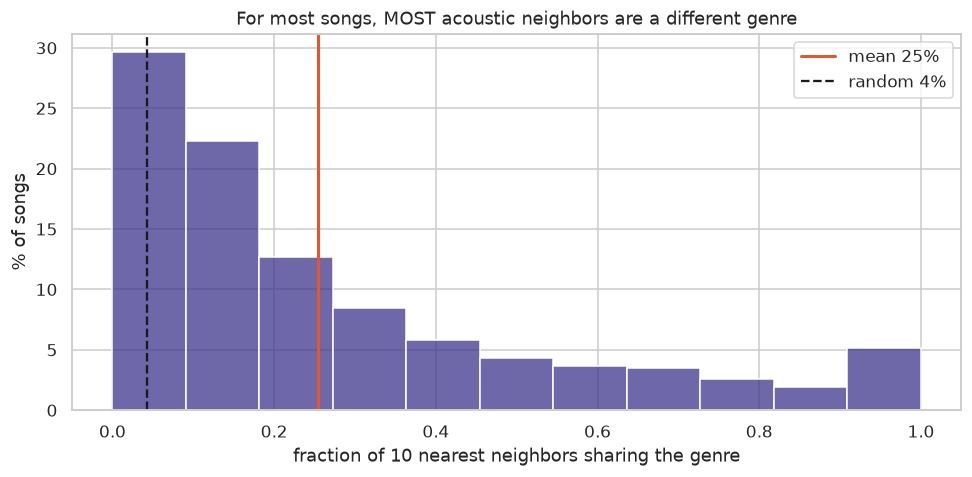

In [7]:
nn = NearestNeighbors(n_neighbors=11).fit(X)
rng = np.random.default_rng(RNG)
q = rng.choice(len(X), size=5000, replace=False)
_, idx = nn.kneighbors(X[q])
same = (y[idx[:,1:]] == y[q][:,None]).mean(1)
base = (pd.Series(y).value_counts(normalize=True)**2).sum()
print(f'neighbors sharing genre: {same.mean():.1%}   random-pair base rate: {base:.1%}   lift: {same.mean()/base:.1f}x')
plt.figure(figsize=(9, 4.5))
sns.histplot(same, bins=11, color='#3d348b', stat='percent')
plt.axvline(same.mean(), color='#e4572e', lw=2, label=f'mean {same.mean():.0%}')
plt.axvline(base, color='k', ls='--', lw=1.5, label=f'random {base:.0%}')
plt.xlabel('fraction of 10 nearest neighbors sharing the genre'); plt.ylabel('% of songs')
plt.title('For most songs, MOST acoustic neighbors are a different genre'); plt.legend()
plt.tight_layout(); plt.show()

### A worked example
Pick one popular track and list its 10 nearest neighbors with their genres — see the mix for yourself.

In [8]:
seed = uniq['popularity'].idxmax()
_, nbrs = nn.kneighbors(X[seed:seed+1], n_neighbors=11)
cols = ['track_name','artist_name','genre','popularity']
print('SEED:', uniq.loc[seed, ['track_name','artist_name','genre']].to_dict())
uniq.loc[nbrs[0][1:], cols].reset_index(drop=True)

SEED: {'track_name': '7 rings', 'artist_name': 'Ariana Grande', 'genre': 'Pop'}


,track_name,artist_name,genre,popularity
0,Quedate a Mi Lado,Jamby el Favo,Reggaeton,38
1,Go Fuck Yourself,Two Feet,Indie,80
2,Falskar ástir,Floni,Electronic,53
3,Blessings,Chance the Rapper,Rap,65
4,7 rings (feat. 2 Chainz) - Remix,Ariana Grande,Dance,73
5,Lonely,Mac Ayres,R&B,57
6,225,Robb Bank$,Hip-Hop,47
7,New House,Toro y Moi,R&B,56
8,She’s a Baby,Zico,R&B,53
9,Me Or Us,Young Thug,Hip-Hop,50


**Takeaway:** a 6× lift — genre *does* predict acoustic similarity better than chance. **But ~3 of every 4 of a song's nearest neighbors are a *different* genre.**

## Step 6 — Do genres separate in feature space? (PCA)
Two views: colored by genre (one big overlapping cloud + a couple of outliers), and a density map showing where songs actually concentrate.

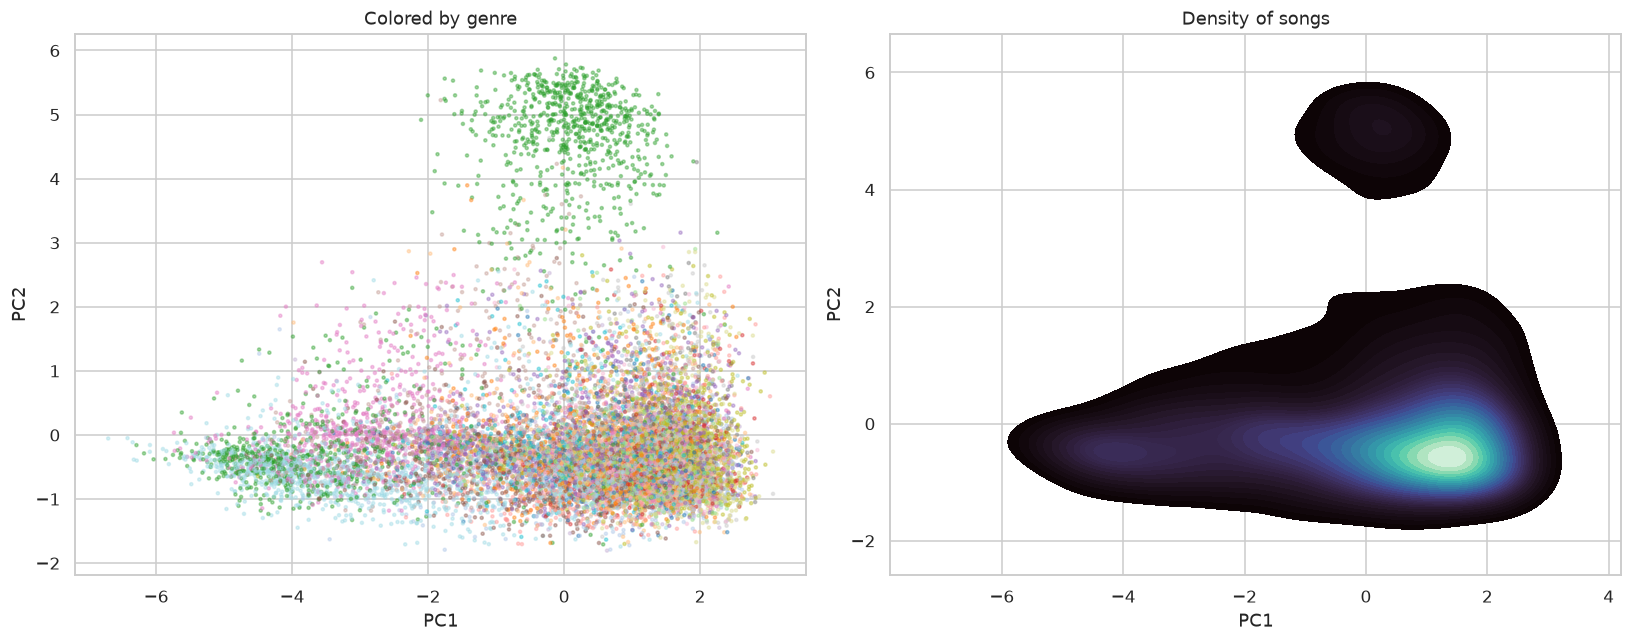

In [9]:
Z = PCA(n_components=2, random_state=RNG).fit_transform(X)
samp = rng.choice(len(X), size=15000, replace=False)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
cats = pd.Categorical(y[samp])
ax[0].scatter(Z[samp,0], Z[samp,1], c=cats.codes, cmap='tab20', s=4, alpha=.4)
ax[0].set_title('Colored by genre'); ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2')
sns.kdeplot(x=Z[samp,0], y=Z[samp,1], fill=True, cmap='mako', levels=30, ax=ax[1])
ax[1].set_title('Density of songs'); ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2')
plt.tight_layout(); plt.show()

## Verdict
**Genres are *real-ish*.** There's a genuine acoustic signal (6× neighbor lift, 7× classifier), but genres overlap heavily — one big cloud with a couple of crisp outliers. Genre is a *weak* summary of how music actually sounds — the most personal, interactive story, and a great candidate for the app.